In [9]:
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [10]:
df=pd.read_csv(r"C:\Users\testuser\Desktop\ml\notebook\data\stud.csv")

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
X=df.drop(columns=['math_score'])
y=df['math_score']

In [14]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [15]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!="O" ]
categorical_features=[feature for feature in df.columns if df[feature].dtype=="O" ]

In [16]:
numeric_features

['math_score', 'reading_score', 'writing_score']

In [17]:
categorical_features

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

In [18]:
num_features=X.select_dtypes(exclude="O").columns
cat_features=X.select_dtypes(include="O").columns


from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer=StandardScaler()
categorical_transformer=OneHotEncoder(handle_unknown="ignore")
preprocessor=ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,num_features),
        ("cat",categorical_transformer,cat_features)
    ]
)



In [19]:
X=preprocessor.fit_transform(X)

In [20]:
X

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]], shape=(1000, 19))

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
X_train.shape

(800, 19)

In [23]:
X_test.shape

(200, 19)

In [24]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2=r2_score(true,predicted)

    return mae,mse,rmse,r2

In [27]:
import numpy as np

In [34]:
models={
    "Linear Regression":LinearRegression(), 
    "Ridge Regression":Ridge(),
    "Lasso Regression":Lasso(),
    "KNN Regressor":KNeighborsRegressor(),
    "Decision Tree Regressor":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "AdaBoost Regressor":AdaBoostRegressor(),
    "Gradient Boosting Regressor":GradientBoostingRegressor(),
    "CatBoost Regressor":CatBoostRegressor(verbose=0),
    "XGB Regressor":XGBRegressor(verbose=0)
}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    mae,mse,rmse,r2=evaluate_model(y_test,y_pred)
    print(f"Model: {list(models.keys())[i]}")
    model_list.append(list(models.keys())[i])
    r2_list.append(r2)
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}")
    print("-"*30)

Model: Linear Regression
MAE: 4.214763142474849
MSE: 29.095169866715466
RMSE: 5.3939938697328405
R2 Score: 0.8804332983749565
------------------------------
Model: Ridge Regression
MAE: 4.211100688014259
MSE: 29.05627219234827
RMSE: 5.3903870169356365
R2 Score: 0.880593148502874
------------------------------
Model: Lasso Regression
MAE: 5.157879138921815
MSE: 42.506332351273414
RMSE: 6.519688056285624
R2 Score: 0.8253200795629732
------------------------------
Model: KNN Regressor
MAE: 5.631
MSE: 52.661
RMSE: 7.256789923926419
R2 Score: 0.7835894375897926
------------------------------
Model: Decision Tree Regressor
MAE: 6.18
MSE: 61.64
RMSE: 7.851114570556208
R2 Score: 0.746690205902562
------------------------------
Model: Random Forest Regressor
MAE: 4.6471583333333335
MSE: 35.780397736111105
RMSE: 5.981671817820759
R2 Score: 0.8529603312255234
------------------------------
Model: AdaBoost Regressor
MAE: 4.7434199277650615
MSE: 36.69981364186245
RMSE: 6.058037111297887
R2 Score: 0

c:\Users\testuser\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:51:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=["Model","R2 Score"]).sort_values(by="R2 Score",ascending=False)

,Model,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
7,Gradient Boosting Regressor,0.872148
5,Random Forest Regressor,0.852960
8,CatBoost Regressor,0.851632
6,AdaBoost Regressor,0.849182
2,Lasso Regression,0.825320
9,XGB Regressor,0.821221
3,KNN Regressor,0.783589
4,Decision Tree Regressor,0.746690


linear regression

In [37]:
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred=lin_reg.predict(X_test)
mae,mse,rmse,r2=evaluate_model(y_test,y_pred)
score=r2_score(y_test,y_pred)*100
print(f"MAE: {mae}")
print(f"MSE: {mse}")    
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")
print(f"Model Accuracy: {score}%")


MAE: 4.214763142474849
MSE: 29.095169866715466
RMSE: 5.3939938697328405
R2 Score: 0.8804332983749565
Model Accuracy: 88.04332983749565%


Text(0, 0.5, 'Predicted Values')

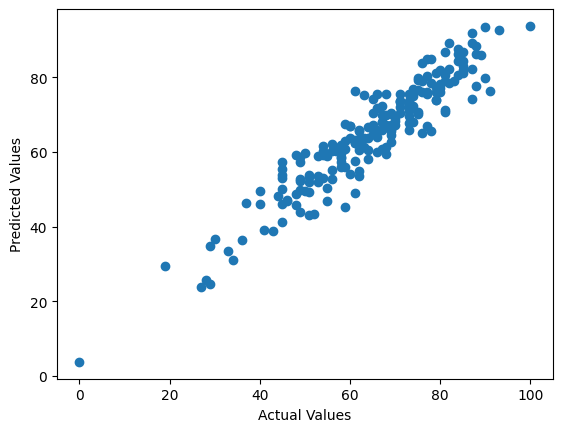

In [40]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

In [41]:
pred_df=pd.DataFrame({"Actual Values":y_test,"Predicted Values":y_pred})
pred_df.head()

,Actual Values,Predicted Values
521,91,76.387970
737,53,58.885970
740,80,76.990265
660,74,76.851804
411,84,87.627378
